# A/B Test Analysis: Checkout Page Redesign

**Note on data:** the dataset used in this notebook is synthetically
generated (see `data/generate_data.py`) to simulate a randomized checkout
page redesign experiment, with a modest, realistic treatment effect built
into the generator. A fixed random seed makes the results reproducible.

## Executive Summary

A checkout page redesign was tested against 30,000 randomly assigned
users, split 50.18% control and 49.82% treatment. No sample ratio mismatch
was detected (chi-square p-value 0.5254), confirming the randomization
was sound. The treatment group converted at 12.57% versus 11.38% for
control, an absolute lift of 1.18 percentage points and a relative lift of
10.37%. The difference was statistically significant (z = 3.15, p =
0.0016), with a 95% confidence interval for the absolute lift of (0.0045,
0.0192), and the direction of the effect held across all three device
segments examined.

Average order value among converting users was also higher in treatment,
44.30 versus 41.90 (t = 4.64, p < 0.001). A post-hoc power check confirmed
the achieved sample size of approximately 15,000 users per group exceeded
the 11,854 per group required for 80% power at the observed effect size,
indicating the test was adequately powered.

## 1. Objective and Scope

A checkout page redesign was tested against the existing checkout flow to
determine whether the redesign improves conversion rate. Users were
randomly assigned to a control group, seeing the existing checkout, or a
treatment group, seeing the redesigned checkout. The primary metric is
conversion rate; average order value among converting users is examined as
a secondary metric.

**Hypotheses:**
- Null hypothesis: conversion rate is the same in both groups.
- Alternative hypothesis: conversion rate differs between groups.

A two-sided test is used at a significance level of 0.05.

In [1]:
# Core libraries used throughout the notebook
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.stats.proportion import proportions_ztest, proportion_confint
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize

sns.set_theme(style="whitegrid", font_scale=0.95)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

In [2]:
df = pd.read_csv("../data/checkout_ab_test.csv")
print(f"Total users: {len(df):,}")
print(df.groupby('group').size())

Total users: 30,000
group
control      15055
treatment    14945
dtype: int64


## 2. Sample Ratio Check

Before evaluating the primary metric, the split between groups is checked
against the intended 50/50 allocation. A meaningful imbalance would
indicate a problem with the randomization itself, which would need to be
resolved before the conversion results could be trusted.

In [3]:
group_counts = df["group"].value_counts()
total = group_counts.sum()
expected = total / 2

chi2_stat, srm_p_value = stats.chisquare(group_counts, f_exp=[expected, expected])

print(f"Control: {group_counts['control']:,} ({group_counts['control'] / total * 100:.2f}%)")
print(f"Treatment: {group_counts['treatment']:,} ({group_counts['treatment'] / total * 100:.2f}%)")
print(f"Sample ratio mismatch chi-square p-value: {srm_p_value:.4f}")
print("No sample ratio mismatch detected." if srm_p_value > 0.01 else "Sample ratio mismatch detected, investigate randomization.")

Control: 15,055 (50.18%)
Treatment: 14,945 (49.82%)
Sample ratio mismatch chi-square p-value: 0.5254
No sample ratio mismatch detected.


## 3. Exploratory Data Analysis

Conversion rate by group is the single most important view for this
analysis and is shown with 95% confidence intervals. A second view breaks
conversion rate down by device to check whether the effect is consistent
across segments, rather than being driven by one device type alone.

In [4]:
summary = df.groupby("group")["converted"].agg(["count", "sum", "mean"])
summary.columns = ["n", "conversions", "conversion_rate"]
ci = summary.apply(lambda r: proportion_confint(r["conversions"], r["n"], alpha=0.05, method="wilson"), axis=1)
summary["ci_low"] = ci.apply(lambda x: x[0])
summary["ci_high"] = ci.apply(lambda x: x[1])
summary = summary.round(4)
summary

,n,conversions,conversion_rate,ci_low,ci_high
group,,,,,
control,15055,1714,0.1138,0.1089,0.1190
treatment,14945,1878,0.1257,0.1204,0.1311


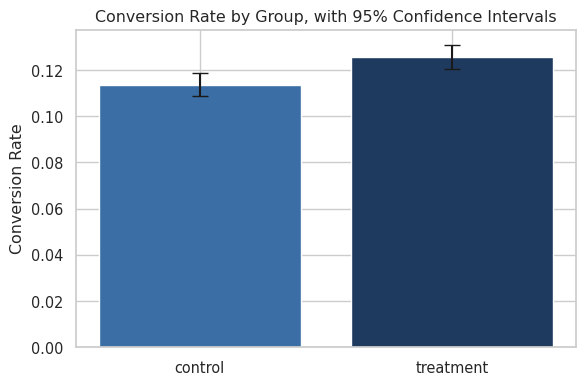

In [5]:
fig, ax = plt.subplots(figsize=(6, 4))
x = np.arange(len(summary))
rates = summary["conversion_rate"].values
errors = [rates - summary["ci_low"].values, summary["ci_high"].values - rates]

ax.bar(x, rates, yerr=errors, capsize=6, color=["#3a6ea5", "#1f3a5f"])
ax.set_xticks(x)
ax.set_xticklabels(summary.index)
ax.set_ylabel("Conversion Rate")
ax.set_title("Conversion Rate by Group, with 95% Confidence Intervals")
plt.tight_layout()
plt.show()

In [6]:
device_summary = df.groupby(["device", "group"])["converted"].mean().unstack().round(4)
device_summary

group,control,treatment
device,,
Desktop,0.1383,0.1449
Mobile,0.0945,0.1094
Tablet,0.1066,0.1219


The treatment group shows a higher conversion rate than control overall,
and the direction of the effect is consistent across all three device
types, which supports treating the overall effect as genuine rather than
an artefact of one segment.

## 4. Statistical Test: Conversion Rate

A two-proportion z-test is used to compare conversion rates between
groups, since the sample size is large and the outcome is binary.

In [7]:
control = df[df["group"] == "control"]
treatment = df[df["group"] == "treatment"]

count = np.array([treatment["converted"].sum(), control["converted"].sum()])
nobs = np.array([len(treatment), len(control)])

z_stat, p_value = proportions_ztest(count, nobs)

rate_control = control["converted"].mean()
rate_treatment = treatment["converted"].mean()
abs_lift = rate_treatment - rate_control
rel_lift = abs_lift / rate_control * 100

diff_se = np.sqrt(rate_control * (1 - rate_control) / len(control) +
                   rate_treatment * (1 - rate_treatment) / len(treatment))
ci_low = abs_lift - 1.96 * diff_se
ci_high = abs_lift + 1.96 * diff_se

print(f"Control conversion rate: {rate_control:.4f}")
print(f"Treatment conversion rate: {rate_treatment:.4f}")
print(f"Absolute lift: {abs_lift:.4f} ({abs_lift * 100:.2f} percentage points)")
print(f"Relative lift: {rel_lift:.2f}%")
print(f"95% CI for absolute lift: ({ci_low:.4f}, {ci_high:.4f})")
print(f"Z-statistic: {z_stat:.2f}, p-value: {p_value:.6f}")

Control conversion rate: 0.1138
Treatment conversion rate: 0.1257
Absolute lift: 0.0118 (1.18 percentage points)
Relative lift: 10.37%
95% CI for absolute lift: (0.0045, 0.0192)
Z-statistic: 3.15, p-value: 0.001628


## 5. Statistical Test: Order Value (Secondary Metric)

Among users who converted, average order value is compared between groups
using a two-sample t-test. This metric is secondary to conversion rate,
since it is only observed for the subset of users who convert, but it
matters for assessing overall revenue impact.

In [8]:
control_values = control.loc[control["converted"] == 1, "order_value"]
treatment_values = treatment.loc[treatment["converted"] == 1, "order_value"]

t_stat, ov_p_value = stats.ttest_ind(treatment_values, control_values, equal_var=False)

print(f"Control average order value (converters only): {control_values.mean():.2f}")
print(f"Treatment average order value (converters only): {treatment_values.mean():.2f}")
print(f"T-statistic: {t_stat:.2f}, p-value: {ov_p_value:.6f}")

Control average order value (converters only): 41.90
Treatment average order value (converters only): 44.30
T-statistic: 4.64, p-value: 0.000004


## 6. Power Check

Post-hoc, the achieved sample size is compared against the minimum sample
size that would have been required to reliably detect the observed effect
at 80% power and a 5% significance level, which confirms whether the test
was adequately powered rather than reaching significance by chance on an
undersized sample.

In [9]:
effect_size = proportion_effectsize(rate_treatment, rate_control)
power_analysis = NormalIndPower()
required_n_per_group = power_analysis.solve_power(
    effect_size=effect_size, alpha=0.05, power=0.8, ratio=1.0
)

print(f"Observed effect size (Cohen's h): {effect_size:.4f}")
print(f"Required sample size per group for 80% power: {required_n_per_group:,.0f}")
print(f"Actual sample size per group: control={len(control):,}, treatment={len(treatment):,}")

Observed effect size (Cohen's h): 0.0364
Required sample size per group for 80% power: 11,854
Actual sample size per group: control=15,055, treatment=14,945


## 7. Findings and Recommendations

The redesigned checkout page produced a statistically significant
improvement in conversion rate, and the effect was consistent in direction
across desktop, mobile, and tablet users rather than being concentrated in
a single segment. The concurrent increase in average order value among
converters indicates the redesign did not trade conversion volume for
smaller basket sizes.

Three recommendations follow from the analysis:

1. The redesigned checkout should be rolled out to 100% of traffic, since
   the lift is both statistically significant and directionally consistent
   across device segments.
2. Mobile carried the lowest conversion rate in both groups (9.45% control,
   10.94% treatment); a dedicated follow-up test focused on the mobile
   checkout flow is likely to yield further gains given it is the largest
   traffic segment.
3. Revenue-per-visitor, which combines the conversion lift and the order
   value lift, should be tracked as the primary success metric in future
   iterations rather than conversion rate alone, since both moved in the
   same favourable direction here.

## 8. Limitations

The dataset is synthetically generated with a fixed treatment effect built
in, so statistical significance here confirms the test correctly recovers
a known effect rather than demonstrating real-world checkout behaviour.
Order value is only observed for converting users, so the secondary metric
comparison is not adjusted for the change in conversion rate itself, which
a full revenue-per-visitor analysis would need to account for. The test
also assumes independent, single-session users; return visits and
cross-device sessions are not modelled.